# Exploratory Data Analysis: Diabetes 130-US Hospitals

**Goal:** Predict whether a diabetic patient will be readmitted within 30 days of discharge.

**Dataset:** UCI ML Repository — Diabetes 130-US Hospitals (1999–2008)  
**Records:** 101,766 | **Features:** 47

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# keep_default_na=False prevents pandas from converting the string "None"
# (a valid A1Cresult / max_glu_serum category) into NaN
df = pd.read_csv('../Data/diabetic_data.csv', na_values=['?'], keep_default_na=False, low_memory=False)

# Binarize target: 1 = readmitted within 30 days, 0 = everything else
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nReadmission counts:\n{df['readmitted'].value_counts()}")
print(f"\nBinary target:\n{df['readmitted_binary'].value_counts()}")
print(f"\nMissing values (top 10):\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

Dataset shape: (101766, 51)

Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Binary target:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Missing values (top 10):
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
dtype: int64


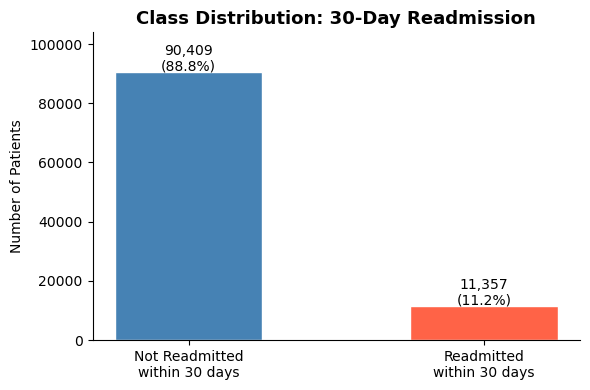

In [2]:
# GRAPH 1: Class Distribution (Bar Chart)
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['readmitted_binary'].value_counts().sort_index()
bars = ax.bar(
    ['Not Readmitted\nwithin 30 days', 'Readmitted\nwithin 30 days'],
    [counts[0], counts[1]],
    color=['steelblue', 'tomato'], edgecolor='white', width=0.5
)
for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

ax.set_title('Class Distribution: 30-Day Readmission', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../Results/EDA_Results/graph1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

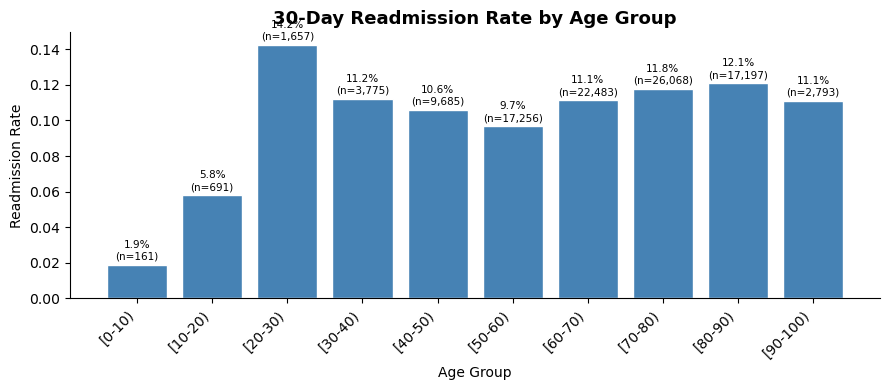

In [3]:
# GRAPH 2: Readmission Rate by Age Group (Bar Chart)
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_stats = (df.groupby('age')['readmitted_binary']
               .agg(['mean', 'count'])
               .reindex(age_order)
               .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(age_stats['age'], age_stats['mean'],
              color='steelblue', edgecolor='white')
for bar, val, n in zip(bars, age_stats['mean'], age_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}\n(n={int(n):,})', ha='center', fontsize=7.5)

ax.set_title('30-Day Readmission Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate')
ax.set_xticks(range(len(age_stats['age'])))
ax.set_xticklabels(age_stats['age'], rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('../Results/EDA_Results/graph2_readmission_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

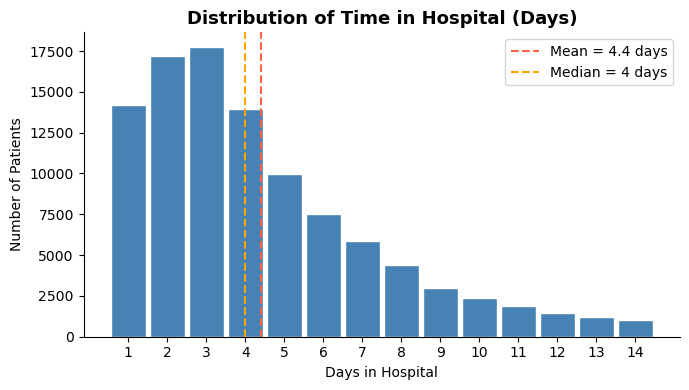

In [4]:
# GRAPH 3: Distribution of Time in Hospital (Histogram)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df['time_in_hospital'], bins=range(1, 16),
        color='steelblue', edgecolor='white', rwidth=0.9, align='left')

ax.axvline(df['time_in_hospital'].mean(), color='tomato', linestyle='--',
           linewidth=1.5, label=f"Mean = {df['time_in_hospital'].mean():.1f} days")
ax.axvline(df['time_in_hospital'].median(), color='orange', linestyle='--',
           linewidth=1.5, label=f"Median = {df['time_in_hospital'].median():.0f} days")

ax.set_title('Distribution of Time in Hospital (Days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(1, 15))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../Results/EDA_Results/graph3_time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

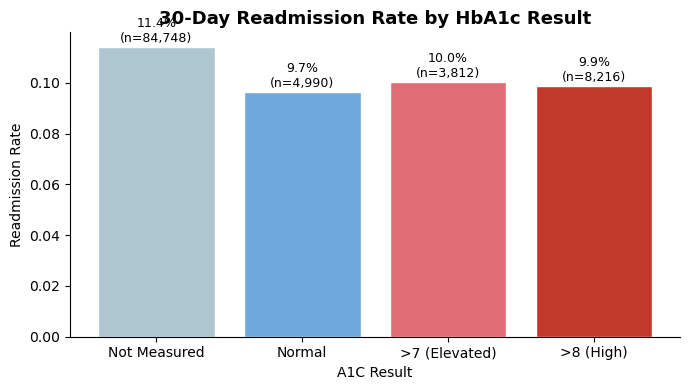

In [5]:
# Readmission Rate by A1C Result (Bar Chart) 
a1c_order = ['None', 'Norm', '>7', '>8']
a1c_stats = (df.groupby('A1Cresult')['readmitted_binary']
               .agg(['mean', 'count'])
               .reindex(a1c_order)
               .reset_index())

a1c_labels = ['Not Measured', 'Normal', '>7 (Elevated)', '>8 (High)']
colors = ['#aec6cf', '#6fa8dc', '#e06c75', '#c0392b']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(a1c_labels, a1c_stats['mean'], color=colors, edgecolor='white')
for bar, val, n in zip(bars, a1c_stats['mean'], a1c_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}\n(n={int(n):,})', ha='center', fontsize=9)

ax.set_title('30-Day Readmission Rate by HbA1c Result', fontsize=13, fontweight='bold')
ax.set_xlabel('A1C Result')
ax.set_ylabel('Readmission Rate')
sns.despine()
plt.tight_layout()
plt.savefig('../Results/EDA_Results/graph4_readmission_by_a1c.png', dpi=150, bbox_inches='tight')
plt.show()

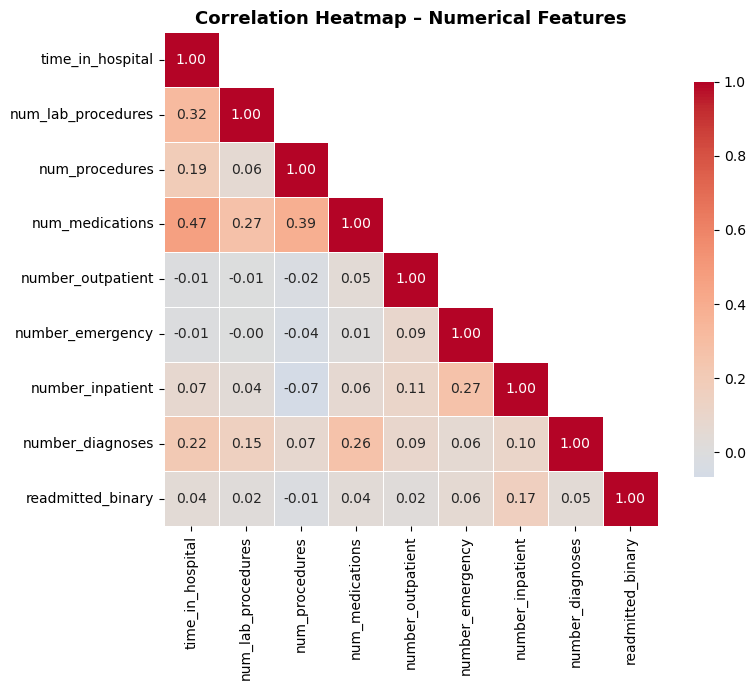

In [6]:
# Correlation Heatmap (Numerical Features) 
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses', 'readmitted_binary']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap \u2013 Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Results/EDA_Results/graph5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

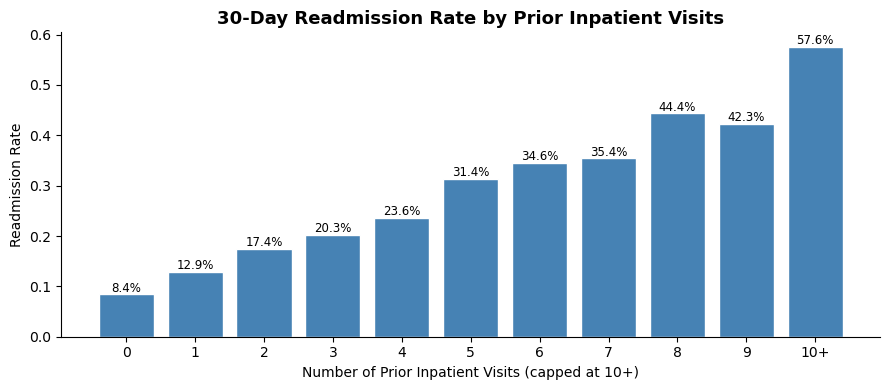

In [7]:
# GRAPH 6: Prior Inpatient Visits vs 30-Day Readmission Rate
inpatient_stats = (df.groupby('number_inpatient')['readmitted_binary']
                     .agg(['mean', 'count'])
                     .reset_index())

# Cap at 10+ for readability
inpatient_stats['group'] = inpatient_stats['number_inpatient'].clip(upper=10)
grouped = (inpatient_stats.groupby('group')
                          .agg(mean=('mean', 'mean'), count=('count', 'sum'))
                          .reset_index())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(grouped['group'], grouped['mean'], color='steelblue', edgecolor='white')
for bar, val in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=8.5)

ax.set_title('30-Day Readmission Rate by Prior Inpatient Visits', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Prior Inpatient Visits (capped at 10+)')
ax.set_ylabel('Readmission Rate')
ax.set_xticks(grouped['group'])
ax.set_xticklabels([str(int(x)) if x < 10 else '10+' for x in grouped['group']])
sns.despine()
plt.tight_layout()
plt.savefig('graph6_inpatient_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

Prior inpatient visits show a clear positive relationship with readmission risk — patients with 0 prior visits have the lowest rate while those with 5+ visits have dramatically higher rates. This confirms `number_inpatient` as the strongest predictor in both models and motivates its use as a top feature.

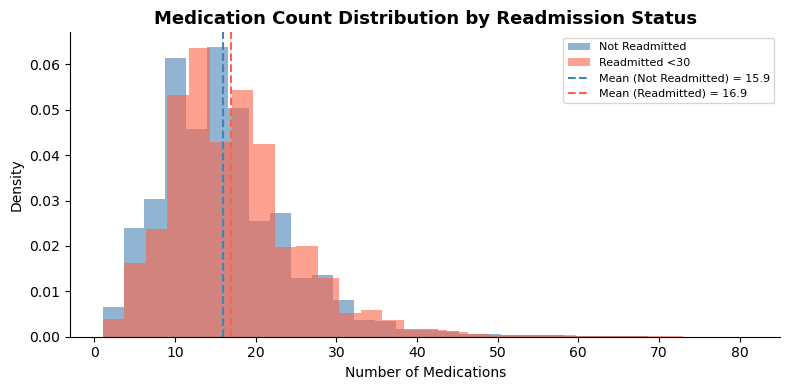

In [8]:
# GRAPH 7: Medication Count Distribution by Readmission Status
not_readmitted = df[df['readmitted_binary'] == 0]['num_medications']
readmitted     = df[df['readmitted_binary'] == 1]['num_medications']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(not_readmitted, bins=30, alpha=0.6, color='steelblue', density=True, label='Not Readmitted')
ax.hist(readmitted,     bins=30, alpha=0.6, color='tomato',    density=True, label='Readmitted <30')
ax.axvline(not_readmitted.mean(), color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Mean (Not Readmitted) = {not_readmitted.mean():.1f}')
ax.axvline(readmitted.mean(), color='tomato', linestyle='--', linewidth=1.5,
           label=f'Mean (Readmitted) = {readmitted.mean():.1f}')

ax.set_title('Medication Count Distribution by Readmission Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Medications')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('graph7_medication_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Readmitted patients have a slightly higher average medication count than non-readmitted patients. The distributions overlap heavily, meaning medication count alone is not a strong separator — but it contributes meaningful signal in combination with other features, which is why `num_medications` ranked in the top features for both models.

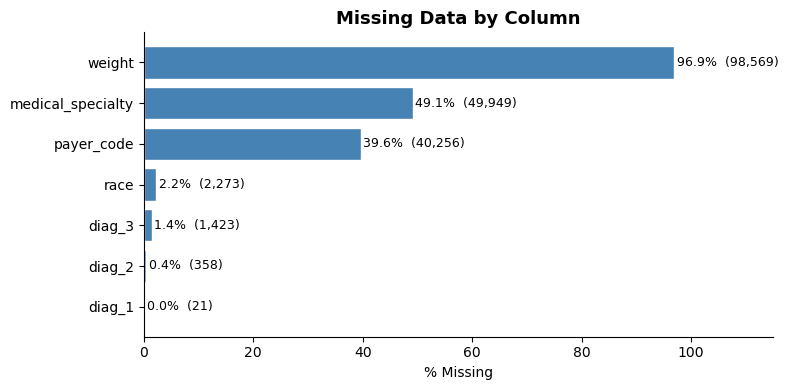

In [9]:
# GRAPH 8: Missing Data by Column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='steelblue', edgecolor='white')
for bar, pct, n in zip(bars, missing_pct.values[::-1], missing.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%  ({n:,})', va='center', fontsize=9)

ax.set_title('Missing Data by Column', fontsize=13, fontweight='bold')
ax.set_xlabel('% Missing')
ax.set_xlim(0, 115)
sns.despine()
plt.tight_layout()
plt.savefig('graph8_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

`weight` is missing for 97% of patients and was dropped in preprocessing. `medical_specialty` (49%) and `payer_code` (40%) were also removed as too sparse to be reliable. `race` has 2,273 missing values — encoded as "Unknown" rather than dropped. The three diagnosis fields (`diag_1/2/3`) have minor missingness handled during preprocessing.

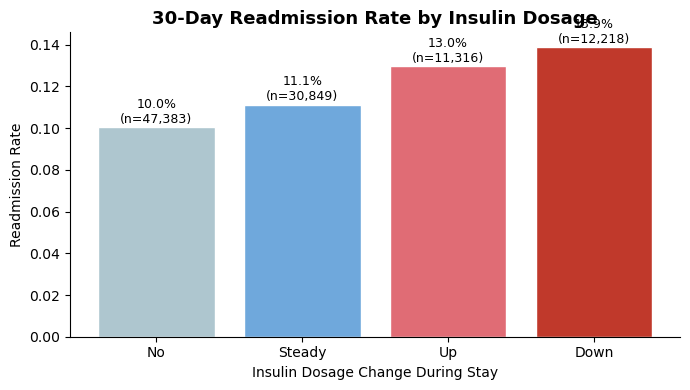

In [10]:
# GRAPH 9: Readmission Rate by Insulin Usage
insulin_order = ['No', 'Steady', 'Up', 'Down']
insulin_stats = (df.groupby('insulin')['readmitted_binary']
                   .agg(['mean', 'count'])
                   .reindex(insulin_order)
                   .reset_index())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#aec6cf', '#6fa8dc', '#e06c75', '#c0392b']
bars = ax.bar(insulin_stats['insulin'], insulin_stats['mean'], color=colors, edgecolor='white')
for bar, val, n in zip(bars, insulin_stats['mean'], insulin_stats['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.1%}\n(n={int(n):,})', ha='center', fontsize=9)

ax.set_title('30-Day Readmission Rate by Insulin Dosage', fontsize=13, fontweight='bold')
ax.set_xlabel('Insulin Dosage Change During Stay')
ax.set_ylabel('Readmission Rate')
sns.despine()
plt.tight_layout()
plt.savefig('graph9_insulin_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

Insulin usage shows modest variation in readmission rates across dosage categories. The differences are small, but insulin was selected as a significant feature in both models — its signal likely comes from interaction with other severity indicators (e.g., `insulin x number_inpatient`) rather than in isolation.

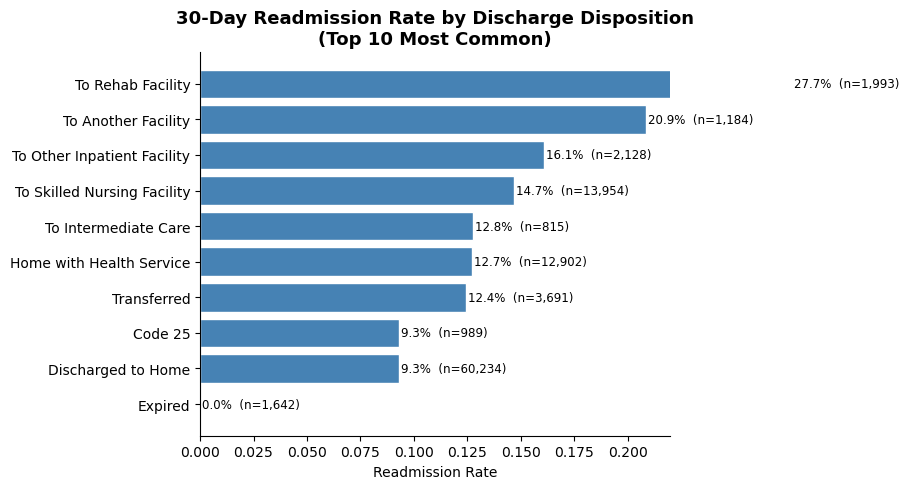

In [11]:
# GRAPH 10: Readmission Rate by Discharge Disposition (Top 10 most common)
disp_map = {
    1:  'Discharged to Home',
    2:  'To Other Inpatient Facility',
    3:  'To Skilled Nursing Facility',
    4:  'To Intermediate Care',
    5:  'To Another Facility',
    6:  'Home with Health Service',
    7:  'Left AMA',
    11: 'Expired',
    18: 'Transferred',
    22: 'To Rehab Facility',
}

disp_stats = (df.groupby('discharge_disposition_id')['readmitted_binary']
                .agg(['mean', 'count'])
                .reset_index())

top_disp = disp_stats.nlargest(10, 'count').copy()
top_disp['label'] = top_disp['discharge_disposition_id'].map(disp_map).fillna(
    'Code ' + top_disp['discharge_disposition_id'].astype(str))
top_disp = top_disp.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_disp['label'], top_disp['mean'], color='steelblue', edgecolor='white')
for bar, val, n in zip(bars, top_disp['mean'], top_disp['count']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}  (n={int(n):,})', va='center', fontsize=8.5)

ax.set_title('30-Day Readmission Rate by Discharge Disposition\n(Top 10 Most Common)', fontsize=13, fontweight='bold')
ax.set_xlabel('Readmission Rate')
ax.set_xlim(0, 0.22)
sns.despine()
plt.tight_layout()
plt.savefig('graph10_discharge_disposition.png', dpi=150, bbox_inches='tight')
plt.show()

Discharge destination strongly predicts readmission risk. Transfers to rehab or other inpatient facilities carry higher rates, while patients sent home have lower rates. This makes clinical sense — complex cases requiring further institutional care are inherently higher risk. Several discharge disposition codes ranked among the top predictors in both the logistic regression and XGBoost models.